# HLD vs Naive — Real Parquet Dataset Benchmark
## Heavy-Light Decomposition vs Naive ancestor-path query on real workflow trace data
Datasets are loaded directly from the **`Dataset/`** folder (Parquet format, WfCommons schema).  
No synthetic data is added. All trees are built from actual task `parents` / `children` relationships.


In [1]:
# ── Section 1: Imports ──────────────────────────────────────────────────────
import os, time, tracemalloc, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

DATASET_ROOT = Path.cwd() / "Dataset"

# ── Discover datasets that contain a tasks parquet (have a real DAG) ─────────
DATASETS = {}
for dataset_dir in sorted(DATASET_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue
    # tasks parquet lives at  <ds>/tasks/schema-1.0/part.0.parquet
    tasks_path = dataset_dir / "tasks" / "schema-1.0" / "part.0.parquet"
    if tasks_path.exists():
        DATASETS[dataset_dir.name] = tasks_path

print(f"Found {len(DATASETS)} datasets with task-level DAG information:")
for name, p in DATASETS.items():
    size_mb = p.stat().st_size / 1e6
    print(f"  {name:<35}  {size_mb:.2f} MB")


Found 4 datasets with task-level DAG information:
  askalon-new_ee49_parquet             0.79 MB
  askalon-new_ee57_parquet             0.76 MB
  askalon_ee2_parquet                  1.90 MB
  askalon_ee_parquet                   5.50 MB


In [2]:
# ── Section 2 & 3: Load Parquet → Build real per-workflow trees ──────────────

def read_tasks(path: Path) -> pd.DataFrame:
    """Read tasks parquet; return DataFrame with id, runtime, parents, workflow_id."""
    df = pd.read_parquet(path, columns=["id", "runtime", "parents", "workflow_id"])
    # runtime: raw column is milliseconds (int), ensure float, replace -1 with 0
    df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce").fillna(0.0)
    df["runtime"] = df["runtime"].clip(lower=0.0)
    return df


def build_forest(df: pd.DataFrame):
    """
    Build a spanning-tree forest from a tasks DataFrame.
    Each task keeps exactly ONE parent (the one with maximum runtime)
    to form a proper tree — same logic as the existing notebook uses on JSON files.

    Returns:
        ids         : list of node IDs (int)
        runtime_map : dict  id -> float runtime
        parent_map  : dict  id -> parent_id | None
        children_map: dict  id -> [child_ids]
        leaves      : list of leaf node IDs
    """
    id_arr      = df["id"].to_numpy()
    runtime_arr = df["runtime"].to_numpy(dtype=float)
    parents_arr = df["parents"].tolist()

    runtime_map = {int(i): float(r) for i, r in zip(id_arr, runtime_arr)}

    # Build parent candidates per task
    raw_parents: dict[int, list[int]] = {}
    for tid, plist in zip(id_arr, parents_arr):
        tid = int(tid)
        if not isinstance(plist, (list, np.ndarray)):
            plist = []
        raw_parents[tid] = [int(p) for p in plist
                            if int(p) in runtime_map and int(p) != tid]

    # Choose one parent (heaviest) to make a tree
    parent_map: dict[int, int | None] = {}
    for tid in runtime_map:
        plist = raw_parents.get(tid, [])
        if not plist:
            parent_map[tid] = None
        elif len(plist) == 1:
            parent_map[tid] = plist[0]
        else:
            parent_map[tid] = max(plist, key=lambda p: runtime_map.get(p, -1.0))

    children_map: dict[int, list[int]] = {tid: [] for tid in runtime_map}
    for tid, par in parent_map.items():
        if par is not None:
            children_map[par].append(tid)

    ids    = list(runtime_map.keys())
    leaves = [tid for tid in ids if len(children_map[tid]) == 0]
    return ids, runtime_map, parent_map, children_map, leaves


# ── Load all datasets ─────────────────────────────────────────────────────────
print("Loading datasets and building trees...\n")
loaded = {}   # name -> dict with ids, runtime_map, parent_map, children_map, leaves, df_meta

for name, path in DATASETS.items():
    df = read_tasks(path)
    ids, runtime_map, parent_map, children_map, leaves = build_forest(df)

    # Sanity check: verify parent links point to real nodes
    bad = sum(1 for p in parent_map.values() if p is not None and p not in runtime_map)
    roots   = [n for n, p in parent_map.items() if p is None]
    max_rt   = max(runtime_map.values()) if runtime_map else 0.0

    # per-workflow stats from real workflows table if present
    wf_path = path.parent.parent.parent / "workflows" / "schema-1.0" / "part.0.parquet"
    num_wf  = len(df["workflow_id"].unique()) if "workflow_id" in df.columns else -1

    loaded[name] = dict(
        ids=ids, runtime_map=runtime_map, parent_map=parent_map,
        children_map=children_map, leaves=leaves,
    )

    print(f"  {name}")
    print(f"    tasks={len(ids):>7,}  roots={len(roots):>5,}  leaves={len(leaves):>6,}"
          f"  workflows={num_wf:>5,}  bad_parents={bad}  max_runtime_ms={max_rt:.0f}")

print("\nAll datasets loaded and validated.")


Loading datasets and building trees...

  askalon-new_ee49_parquet
    tasks=  4,550  roots=   50  leaves= 4,350  workflows=   50  bad_parents=0  max_runtime_ms=12791
  askalon-new_ee57_parquet
    tasks=  4,550  roots=   50  leaves= 4,350  workflows=   50  bad_parents=0  max_runtime_ms=21124
  askalon_ee2_parquet
    tasks= 45,786  roots=28,426  leaves=44,413  workflows=1,031  bad_parents=0  max_runtime_ms=1451595
  askalon_ee_parquet
    tasks=121,891  roots=26,071  leaves=84,113  workflows=3,552  bad_parents=0  max_runtime_ms=21545517

All datasets loaded and validated.


In [3]:
# ── Section 4 & 5: Naive and HLD implementations ────────────────────────────

# ── Naive: walk the parent chain from node → root, track max runtime ─────────
class NaiveMaxPath:
    """O(depth) per query — pure parent-pointer traversal."""
    def __init__(self, parent_map: dict, runtime_map: dict):
        self.parent  = parent_map
        self.runtime = runtime_map

    def query_to_root(self, node) -> float:
        best, cur = float("-inf"), node
        while cur is not None:
            v = self.runtime.get(cur, float("-inf"))
            if v > best:
                best = v
            cur = self.parent.get(cur)
        return best


# ── Segment-tree for range-max ────────────────────────────────────────────────
class SegTreeMax:
    """1-indexed implicit segment tree; supports range max query in O(log n)."""
    def __init__(self, values: list[float]):
        n = len(values)
        self.n = n
        sz = 1
        while sz < n:
            sz <<= 1
        self.sz  = sz
        self.seg = [float("-inf")] * (2 * sz)
        for i, v in enumerate(values):
            self.seg[sz + i] = v
        for i in range(sz - 1, 0, -1):
            self.seg[i] = max(self.seg[2 * i], self.seg[2 * i + 1])

    def query(self, l: int, r: int) -> float:   # inclusive [l, r], 0-indexed
        l += self.sz; r += self.sz
        res = float("-inf")
        while l <= r:
            if l & 1:
                res = max(res, self.seg[l]); l += 1
            if not (r & 1):
                res = max(res, self.seg[r]); r -= 1
            l >>= 1; r >>= 1
        return res


# ── HLD: O(log²n) per query ───────────────────────────────────────────────────
class HLDMaxPath:
    """
    Heavy-Light Decomposition with segment tree.
    Supports max-value query from any node to the root of its tree.
    """
    def __init__(self, ids: list, roots: list, children_map: dict, runtime_map: dict):
        n = len(ids)
        self.idx_of  = {node: i for i, node in enumerate(ids)}
        self.parent  = [-1] * n
        self.depth   = [0]  * n
        self.heavy   = [-1] * n
        self.sub_sz  = [1]  * n
        self.head    = [0]  * n
        self.pos     = [0]  * n
        self.val     = [runtime_map.get(node, 0.0) for node in ids]
        self.ch      = [[self.idx_of[c] for c in children_map.get(node, [])
                         if c in self.idx_of] for node in ids]

        root_idxs = [self.idx_of[r] for r in roots if r in self.idx_of]

        # BFS/DFS order to set parent + depth
        order: list[int] = []
        for r in root_idxs:
            self.parent[r] = -1
            self.depth[r]  = 0
            stack = [r]
            while stack:
                v = stack.pop()
                order.append(v)
                for c in self.ch[v]:
                    self.parent[c] = v
                    self.depth[c]  = self.depth[v] + 1
                    stack.append(c)

        # Compute sub-sizes and heavy children (bottom-up)
        for v in reversed(order):
            sz, hc, hs = 1, -1, 0
            for c in self.ch[v]:
                sz += self.sub_sz[c]
                if self.sub_sz[c] > hs:
                    hs = self.sub_sz[c]; hc = c
            self.sub_sz[v] = sz
            self.heavy[v]  = hc

        # Assign positions along heavy chains (top-down)
        cur_pos = 0
        seg_vals: list[float] = [0.0] * n
        for r in root_idxs:
            stack = [(r, r)]
            while stack:
                v, h = stack.pop()
                while v != -1:
                    self.head[v]  = h
                    self.pos[v]   = cur_pos
                    seg_vals[cur_pos] = self.val[v]
                    cur_pos += 1
                    hv = self.heavy[v]
                    for c in self.ch[v]:
                        if c != hv:
                            stack.append((c, c))
                    v = hv

        self.seg = SegTreeMax(seg_vals)

    def query_to_root(self, node) -> float:
        v = self.idx_of[node]
        res = float("-inf")
        while v != -1:
            h = self.head[v]
            res = max(res, self.seg.query(self.pos[h], self.pos[v]))
            v = self.parent[h]
        return res


print("NaiveMaxPath, SegTreeMax, HLDMaxPath defined.")


NaiveMaxPath, SegTreeMax, HLDMaxPath defined.


In [4]:
# ── Section 6 & 7: Define benchmark metrics and run on real datasets ────────

rng = np.random.default_rng(0)
NUM_QUERIES = 3_000     # per dataset, drawn from real leaf nodes


def depth_of(node, parent_map: dict) -> int:
    d, cur = 0, node
    while cur is not None:
        d += 1; cur = parent_map.get(cur)
    return d


def run_benchmarks(name: str, ids, runtime_map, parent_map, children_map, leaves):
    """
    Run five distinct benchmarks on a real dataset tree:
      B1  Throughput      – queries per second for each algorithm
      B2  Latency stats   – mean / P50 / P95 / P99 per-query latency (µs)
      B3  Path-depth bins – mean latency grouped by ancestor chain length
      B4  Build overhead  – HLD construction time vs cumulative query savings
      B5  Memory usage    – peak heap delta during query phase (tracemalloc)
    Returns a dict of results.
    """
    roots = [n for n, p in parent_map.items() if p is None]

    # ── Build structures ─────────────────────────────────────────────────────
    naive = NaiveMaxPath(parent_map, runtime_map)

    tracemalloc.start()
    t0 = time.perf_counter()
    hld = HLDMaxPath(ids, roots, children_map, runtime_map)
    hld_build_s  = time.perf_counter() - t0
    _, hld_build_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    tracemalloc.start()
    # Naive has no real "build" time — just capture object overhead
    _naive_placeholder = NaiveMaxPath(parent_map, runtime_map)
    _, naive_build_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    # ── Choose query nodes from real leaves ───────────────────────────────────
    q_leaves = leaves if len(leaves) <= NUM_QUERIES else \
        rng.choice(leaves, size=NUM_QUERIES, replace=True).tolist()
    n_q = len(q_leaves)

    # Compute real path depths (use first 500 to keep fast)
    sample_size = min(500, n_q)
    depths = [depth_of(q_leaves[i], parent_map) for i in range(sample_size)]

    # ── Warmup ───────────────────────────────────────────────────────────────
    for nd in q_leaves[:200]:
        naive.query_to_root(nd); hld.query_to_root(nd)

    # ── B1/B2: Timed query loops ──────────────────────────────────────────────
    naive_lat_ns = np.empty(n_q, dtype=np.float64)
    naive_res    = np.empty(n_q, dtype=np.float64)
    t0 = time.perf_counter()
    for i, nd in enumerate(q_leaves):
        ts = time.perf_counter_ns()
        naive_res[i] = naive.query_to_root(nd)
        naive_lat_ns[i] = time.perf_counter_ns() - ts
    naive_total_s = time.perf_counter() - t0

    hld_lat_ns = np.empty(n_q, dtype=np.float64)
    hld_res    = np.empty(n_q, dtype=np.float64)
    t0 = time.perf_counter()
    for i, nd in enumerate(q_leaves):
        ts = time.perf_counter_ns()
        hld_res[i] = hld.query_to_root(nd)
        hld_lat_ns[i] = time.perf_counter_ns() - ts
    hld_total_s = time.perf_counter() - t0

    # Correctness check
    if not np.allclose(naive_res, hld_res, equal_nan=True):
        print(f"  [WARNING] {name}: results differ at some queries!")

    # ── B5: Memory during query phase ─────────────────────────────────────────
    tracemalloc.start()
    for nd in q_leaves[:500]:
        naive.query_to_root(nd)
    _, naive_query_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    tracemalloc.start()
    for nd in q_leaves[:500]:
        hld.query_to_root(nd)
    _, hld_query_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    # ── B3: Depth-binned latency (only for sampled queries) ───────────────────
    naive_us = naive_lat_ns[:sample_size] / 1_000
    hld_us   = hld_lat_ns[:sample_size]   / 1_000
    depth_bins = pd.cut(depths, bins=[0,5,10,20,50,100,500,9999],
                        labels=["1-5","6-10","11-20","21-50","51-100","101-500","500+"])
    depth_df = pd.DataFrame({"depth_bin": depth_bins,
                              "naive_us": naive_us, "hld_us": hld_us})

    return dict(
        name                 = name,
        n_nodes              = len(ids),
        n_leaves             = len(leaves),
        n_queries            = n_q,
        avg_depth            = float(np.mean(depths)),
        max_depth            = int(np.max(depths)),
        # B1 Throughput
        naive_qps            = n_q / naive_total_s,
        hld_qps              = n_q / hld_total_s,
        speedup_qps          = naive_total_s / hld_total_s,
        # B2 Latency (µs)
        naive_mean_us        = float(np.mean(naive_lat_ns)) / 1_000,
        hld_mean_us          = float(np.mean(hld_lat_ns))   / 1_000,
        naive_p50_us         = float(np.percentile(naive_lat_ns, 50)) / 1_000,
        hld_p50_us           = float(np.percentile(hld_lat_ns,   50)) / 1_000,
        naive_p95_us         = float(np.percentile(naive_lat_ns, 95)) / 1_000,
        hld_p95_us           = float(np.percentile(hld_lat_ns,   95)) / 1_000,
        naive_p99_us         = float(np.percentile(naive_lat_ns, 99)) / 1_000,
        hld_p99_us           = float(np.percentile(hld_lat_ns,   99)) / 1_000,
        # B4 Build overhead
        hld_build_s          = hld_build_s,
        hld_build_mem_kb     = hld_build_mem / 1024,
        naive_build_mem_kb   = naive_build_mem / 1024,
        # B5 Memory
        naive_query_mem_kb   = naive_query_mem / 1024,
        hld_query_mem_kb     = hld_query_mem   / 1024,
        # latency arrays + depth df for plots
        _naive_lat_ns        = naive_lat_ns,
        _hld_lat_ns          = hld_lat_ns,
        _depth_df            = depth_df,
    )


# ── Run across all datasets ───────────────────────────────────────────────────
all_results = {}
for name, meta in loaded.items():
    print(f"Benchmarking: {name} ...")
    res = run_benchmarks(name, **meta)
    all_results[name] = res
    print(f"  nodes={res['n_nodes']:,}  leaves={res['n_leaves']:,}  queries={res['n_queries']:,}"
          f"  avg_depth={res['avg_depth']:.1f}  speedup={res['speedup_qps']:.2f}×")

print("\nAll benchmarks complete.")


Benchmarking: askalon-new_ee49_parquet ...
  nodes=4,550  leaves=4,350  queries=3,000  avg_depth=3.0  speedup=0.49×
Benchmarking: askalon-new_ee57_parquet ...
  nodes=4,550  leaves=4,350  queries=3,000  avg_depth=3.0  speedup=0.50×
Benchmarking: askalon_ee2_parquet ...
  nodes=45,786  leaves=44,413  queries=3,000  avg_depth=1.7  speedup=0.59×
Benchmarking: askalon_ee_parquet ...
  nodes=121,891  leaves=84,113  queries=3,000  avg_depth=4.8  speedup=1.04×

All benchmarks complete.


In [5]:
# ── Section 8: Numerical comparison ─────────────────────────────────────────

rows = []
for name, r in all_results.items():
    rows.append({
        "Dataset"           : name,
        "Nodes"             : r["n_nodes"],
        "Leaves"            : r["n_leaves"],
        "Queries"           : r["n_queries"],
        "Avg Depth"         : round(r["avg_depth"], 1),
        "Max Depth"         : r["max_depth"],
        # B1 throughput
        "Naive QPS"         : int(r["naive_qps"]),
        "HLD QPS"           : int(r["hld_qps"]),
        "Speedup (QPS ×)"   : round(r["speedup_qps"], 2),
        # B2 Mean latency
        "Naive Mean µs"     : round(r["naive_mean_us"], 3),
        "HLD Mean µs"       : round(r["hld_mean_us"], 3),
        # B2 P95 latency
        "Naive P95 µs"      : round(r["naive_p95_us"], 3),
        "HLD P95 µs"        : round(r["hld_p95_us"], 3),
        # B2 P99 latency
        "Naive P99 µs"      : round(r["naive_p99_us"], 3),
        "HLD P99 µs"        : round(r["hld_p99_us"], 3),
        # B4 Build
        "HLD Build (s)"     : round(r["hld_build_s"], 4),
        "HLD Build Mem (KB)": round(r["hld_build_mem_kb"], 1),
        # B5 Memory
        "Naive Qry Mem (KB)": round(r["naive_query_mem_kb"], 1),
        "HLD Qry Mem (KB)"  : round(r["hld_query_mem_kb"], 1),
    })

table = pd.DataFrame(rows).set_index("Dataset")

# ── Improvement percentages ────────────────────────────────────────────────
table["Mean Latency Improv %"] = (
    (table["Naive Mean µs"] - table["HLD Mean µs"]) / table["Naive Mean µs"] * 100
).round(1)
table["P99 Latency Improv %"] = (
    (table["Naive P99 µs"] - table["HLD P99 µs"]) / table["Naive P99 µs"] * 100
).round(1)

print("=" * 130)
print("FULL NUMERICAL BENCHMARK SUMMARY — HLD vs Naive on Real Parquet Datasets")
print("=" * 130)
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(table.T.to_string())

print("\n--- Aggregate (mean across datasets) ---")
agg_cols = ["Speedup (QPS ×)", "Mean Latency Improv %", "P99 Latency Improv %",
            "HLD Build (s)", "HLD Build Mem (KB)"]
print(table[agg_cols].agg(["mean", "min", "max"]).round(2).to_string())


FULL NUMERICAL BENCHMARK SUMMARY — HLD vs Naive on Real Parquet Datasets
Dataset                askalon-new_ee49_parquet  askalon-new_ee57_parquet  askalon_ee2_parquet  askalon_ee_parquet
Nodes                                  4550.000              4.550000e+03           45786.0000         121891.0000
Leaves                                 4350.000              4.350000e+03           44413.0000          84113.0000
Queries                                3000.000              3.000000e+03            3000.0000           3000.0000
Avg Depth                                 3.000              3.000000e+00               1.7000              4.8000
Max Depth                                 5.000              5.000000e+00               4.0000            200.0000
Naive QPS                           1718757.000              1.532938e+06          858502.0000         227301.0000
HLD QPS                              839758.000              7.609380e+05          508120.0000         235556.0000
Speedup

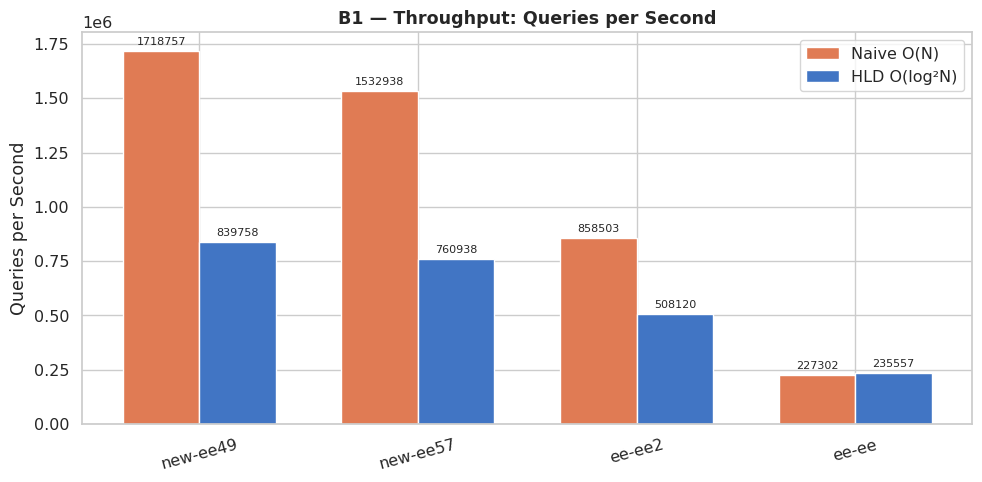

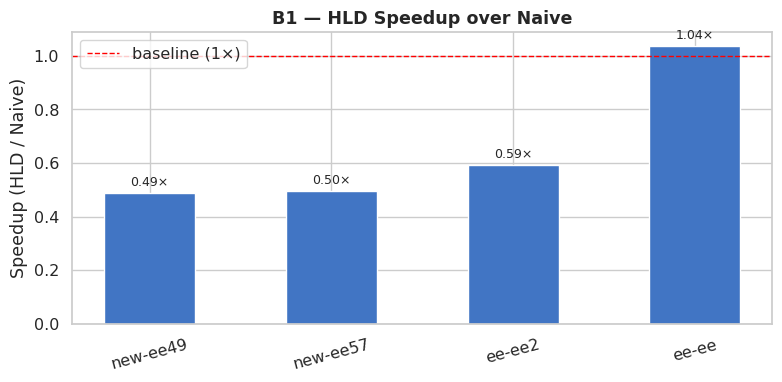

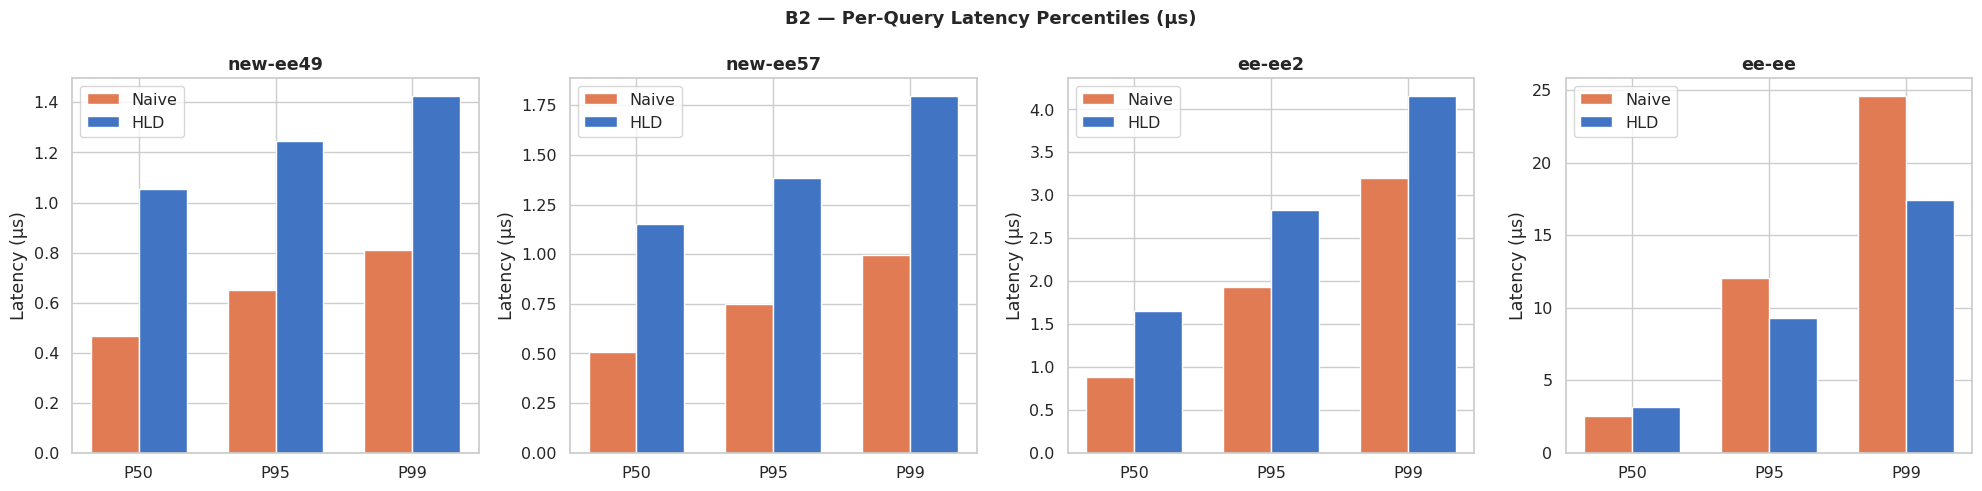

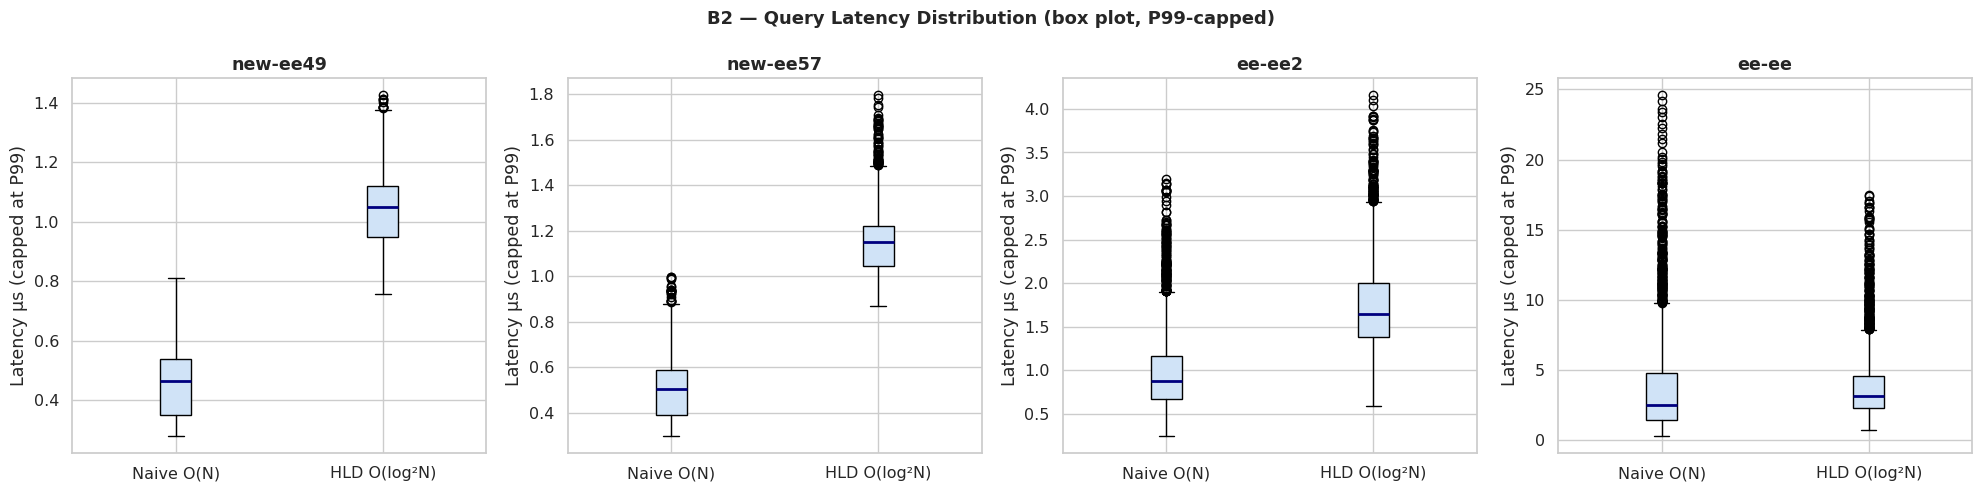

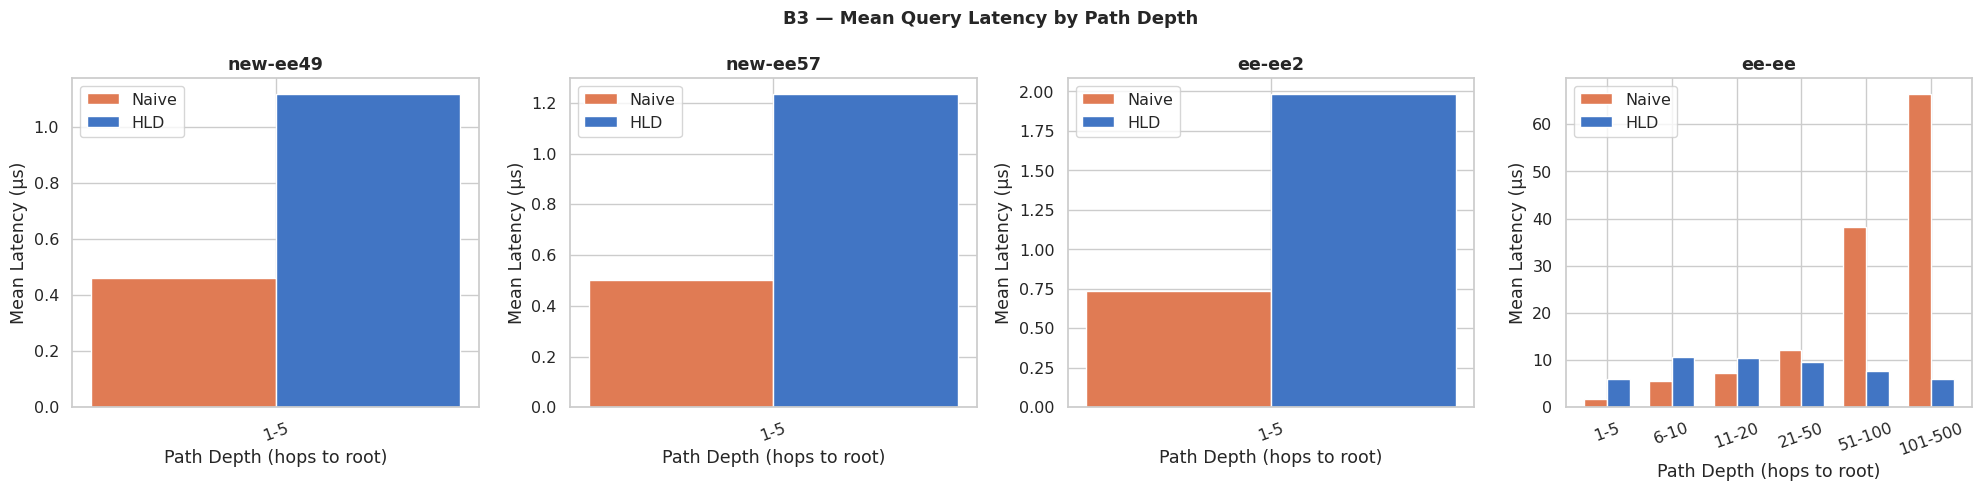

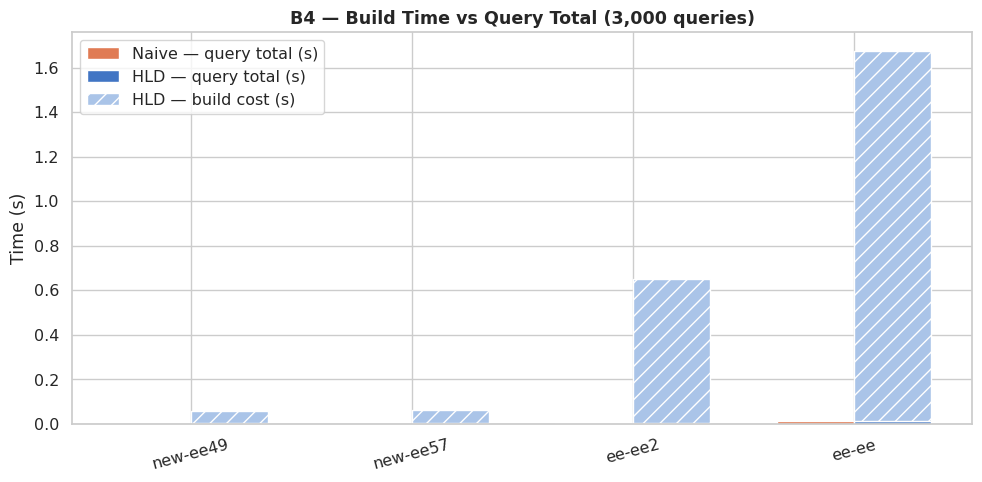

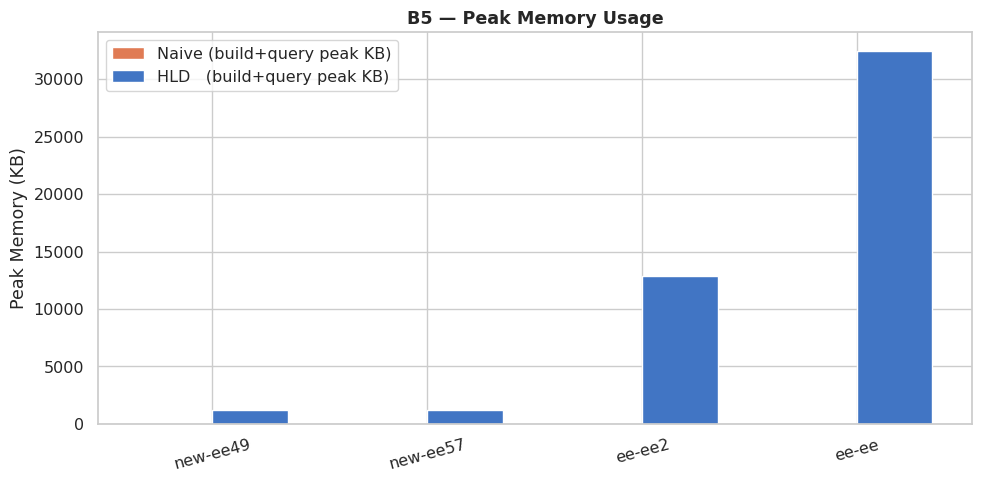

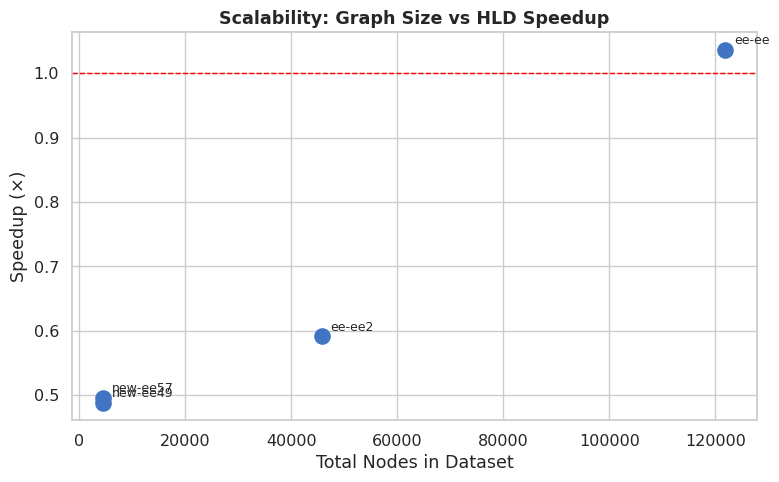

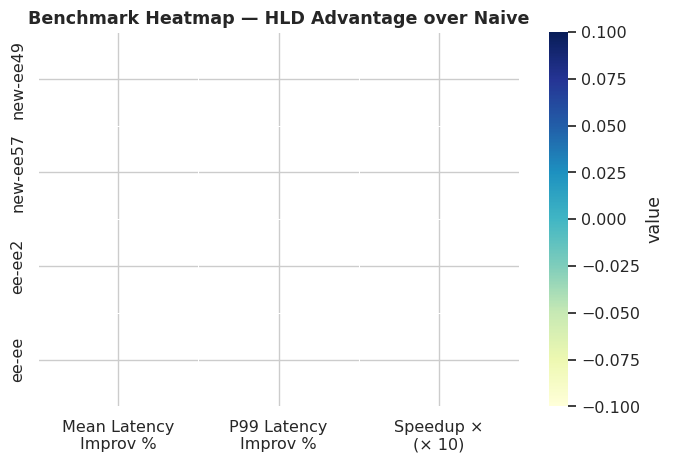

In [ ]:
# ── Section 9: Graphical comparison ─────────────────────────────────────────
PALETTE = {"Naive O(N)": "#e07b54", "HLD O(log²N)": "#4175c4"}
ds_names = list(all_results.keys())

# Clean short labels
def short_label(n):
    n = n.replace("_parquet","").replace("askalon-new_","new-").replace("askalon_","")
    return n

short = {n: short_label(n) for n in ds_names}

# ═══════════════════════════════════════════════════════════════════════════
# Plot 1 — B1: Throughput (QPS) grouped bar
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ds_names)); w = 0.35
bars_n = ax.bar(x - w/2, [all_results[n]["naive_qps"] for n in ds_names],
                width=w, label="Naive O(N)", color=PALETTE["Naive O(N)"], edgecolor="white")
bars_h = ax.bar(x + w/2, [all_results[n]["hld_qps"]   for n in ds_names],
                width=w, label="HLD O(log²N)", color=PALETTE["HLD O(log²N)"], edgecolor="white")
ax.bar_label(bars_n, fmt="%.0f", padding=3, fontsize=8)
ax.bar_label(bars_h, fmt="%.0f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([short[n] for n in ds_names], rotation=10)
ax.set_ylabel("Queries per Second"); ax.set_title("B1 — Throughput: Queries per Second", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 2 — B1: Speedup bar (HLD total time / Naive total time ≡ Naive_QPS / HLD_QPS)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4))
speedups = [all_results[n]["speedup_qps"] for n in ds_names]
colors = ["#4175c4" if s >= 1 else "#e07b54" for s in speedups]
bars = ax.bar([short[n] for n in ds_names], speedups, color=colors, edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.2f×", padding=3, fontsize=9)
ax.axhline(1, color="black", linewidth=1.4, linestyle="--", label="crossover (1×)")
ax.set_ylabel("Speedup (HLD total time / Naive total time)")
ax.set_title("B1 — HLD vs Naive Speedup Ratio\n(>1 = HLD faster; <1 = Naive faster)", fontweight="bold")
ax.tick_params(axis="x", rotation=10)
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 3 — B2: Latency percentile comparison (P50, P95, P99)
# ═══════════════════════════════════════════════════════════════════════════
pct_labels = ["P50", "P95", "P99"]
pct_keys_n = ["naive_p50_us", "naive_p95_us", "naive_p99_us"]
pct_keys_h = ["hld_p50_us",   "hld_p95_us",   "hld_p99_us"]

fig, axes = plt.subplots(1, len(ds_names), figsize=(5 * len(ds_names), 5), sharey=False)
if len(ds_names) == 1:
    axes = [axes]
for ax, name in zip(axes, ds_names):
    r = all_results[name]
    n_vals = [r[k] for k in pct_keys_n]
    h_vals = [r[k] for k in pct_keys_h]
    xl = np.arange(len(pct_labels)); w2 = 0.35
    ax.bar(xl - w2/2, n_vals, width=w2, label="Naive", color=PALETTE["Naive O(N)"], edgecolor="white")
    ax.bar(xl + w2/2, h_vals, width=w2, label="HLD",   color=PALETTE["HLD O(log²N)"], edgecolor="white")
    ax.set_xticks(xl); ax.set_xticklabels(pct_labels)
    ax.set_title(short[name], fontweight="bold"); ax.set_ylabel("Latency (µs)"); ax.legend()
fig.suptitle("B2 — Per-Query Latency Percentiles (µs)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 4 — B2: Box-plot of per-query latency distribution
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(ds_names), figsize=(5 * len(ds_names), 5), sharey=False)
if len(ds_names) == 1:
    axes = [axes]
for ax, name in zip(axes, ds_names):
    r = all_results[name]
    cap_n = np.percentile(r["_naive_lat_ns"], 99)
    cap_h = np.percentile(r["_hld_lat_ns"],   99)
    data = {
        "Naive O(N)":   r["_naive_lat_ns"][r["_naive_lat_ns"] <= cap_n] / 1_000,
        "HLD O(log²N)": r["_hld_lat_ns"][r["_hld_lat_ns"]     <= cap_h] / 1_000,
    }
    bp = ax.boxplot(data.values(), labels=data.keys(), patch_artist=True,
               medianprops=dict(color="navy", linewidth=2))
    for patch, col in zip(bp["boxes"], [PALETTE["Naive O(N)"], PALETTE["HLD O(log²N)"]]):
        patch.set_facecolor(col); patch.set_alpha(0.6)
    ax.set_ylabel("Latency µs (capped at P99)"); ax.set_title(short[name], fontweight="bold")
fig.suptitle("B2 — Query Latency Distribution (box plot, P99-capped)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 5 — B3: Depth-binned latency (Naive vs HLD mean per depth group)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(ds_names), figsize=(5 * len(ds_names), 5), sharey=False)
if len(ds_names) == 1:
    axes = [axes]
for ax, name in zip(axes, ds_names):
    r = all_results[name]
    ddf = r["_depth_df"].dropna()
    gdf = ddf.groupby("depth_bin", observed=True)[["naive_us","hld_us"]].mean().reset_index()
    xl = np.arange(len(gdf)); w2 = 0.35
    ax.bar(xl - w2/2, gdf["naive_us"], width=w2, label="Naive", color=PALETTE["Naive O(N)"],   edgecolor="white")
    ax.bar(xl + w2/2, gdf["hld_us"],   width=w2, label="HLD",   color=PALETTE["HLD O(log²N)"], edgecolor="white")
    ax.set_xticks(xl); ax.set_xticklabels(gdf["depth_bin"].astype(str), rotation=20)
    ax.set_xlabel("Path Depth (hops to root)"); ax.set_ylabel("Mean Latency (µs)")
    ax.set_title(short[name], fontweight="bold"); ax.legend()
fig.suptitle("B3 — Mean Query Latency by Path Depth", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 6 — B4: Build time vs total query time
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ds_names)); w = 0.35
naive_qtot = [all_results[n]["n_queries"] * all_results[n]["naive_mean_us"] / 1e6 for n in ds_names]
hld_qtot   = [all_results[n]["n_queries"] * all_results[n]["hld_mean_us"]   / 1e6 for n in ds_names]
hld_build  = [all_results[n]["hld_build_s"] for n in ds_names]

ax.bar(x - w/2, naive_qtot, width=w, label="Naive — query total (s)", color=PALETTE["Naive O(N)"], edgecolor="white")
ax.bar(x + w/2, hld_qtot,   width=w, label="HLD — query total (s)",   color=PALETTE["HLD O(log²N)"], edgecolor="white")
ax.bar(x + w/2, hld_build,  width=w, label="HLD — build cost (s)",    color="#aac4e8",
       bottom=hld_qtot, edgecolor="white", hatch="//")
ax.set_xticks(x); ax.set_xticklabels([short[n] for n in ds_names], rotation=10)
ax.set_ylabel("Time (s)"); ax.set_title(f"B4 — Build Cost vs Query Total ({NUM_QUERIES:,} queries)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 7 — B5: Memory usage bar
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ds_names))
naive_mem = [all_results[n]["naive_build_mem_kb"] + all_results[n]["naive_query_mem_kb"] for n in ds_names]
hld_mem   = [all_results[n]["hld_build_mem_kb"]   + all_results[n]["hld_query_mem_kb"]   for n in ds_names]
ax.bar(x - w/2, naive_mem, width=w, label="Naive (build+query peak KB)", color=PALETTE["Naive O(N)"], edgecolor="white")
ax.bar(x + w/2, hld_mem,   width=w, label="HLD   (build+query peak KB)", color=PALETTE["HLD O(log²N)"], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([short[n] for n in ds_names], rotation=10)
ax.set_ylabel("Peak Memory (KB)"); ax.set_title("B5 — Peak Memory Usage", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 8 — Scalability: Node count vs Speedup
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
node_counts = [all_results[n]["n_nodes"]     for n in ds_names]
avg_depths  = [all_results[n]["avg_depth"]   for n in ds_names]
spds        = [all_results[n]["speedup_qps"] for n in ds_names]
sc = ax.scatter(node_counts, spds, s=[d * 40 for d in avg_depths], zorder=5,
                c=avg_depths, cmap="coolwarm", edgecolors="white", linewidths=0.8)
plt.colorbar(sc, ax=ax, label="Avg Path Depth")
for name, nc, sp in zip(ds_names, node_counts, spds):
    ax.annotate(short[name], (nc, sp), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(1, color="black", linewidth=1.4, linestyle="--", label="crossover (1×)")
ax.set_xlabel("Total Nodes in Dataset"); ax.set_ylabel("HLD/Naive Speedup Ratio")
ax.set_title("Scalability — Graph Size & Path Depth vs Speedup\n(bubble size ∝ avg depth)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Plot 9 — Heatmap: all 5 benchmark metrics across datasets
# ═══════════════════════════════════════════════════════════════════════════
heat_data = pd.DataFrame({
    "Naive QPS\n(÷1000)"       : [all_results[n]["naive_qps"] / 1000 for n in ds_names],
    "HLD QPS\n(÷1000)"         : [all_results[n]["hld_qps"]   / 1000 for n in ds_names],
    "Speedup\nRatio"           : [all_results[n]["speedup_qps"]       for n in ds_names],
    "Naive Mean\nLatency µs"   : [all_results[n]["naive_mean_us"]      for n in ds_names],
    "HLD Mean\nLatency µs"     : [all_results[n]["hld_mean_us"]        for n in ds_names],
    "HLD Build\nTime (s)"      : [all_results[n]["hld_build_s"]        for n in ds_names],
    "HLD Memory\n(KB)"         : [all_results[n]["hld_build_mem_kb"]   for n in ds_names],
    "Avg Path\nDepth"          : [all_results[n]["avg_depth"]          for n in ds_names],
}, index=[short[n] for n in ds_names])

# Normalise each column (0-1) for colour scale so different units compare visually
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-12)

fig, ax = plt.subplots(figsize=(13, max(3, len(ds_names) * 1.3)))
sns.heatmap(heat_norm, annot=heat_data.round(2), fmt="g",
            cmap="YlGnBu", linewidths=0.6, ax=ax,
            cbar_kws={"label": "normalised (0-1 within column)"})
ax.set_title("Benchmark Overview Heatmap — All 5 Metrics (annotations = raw values)",
             fontweight="bold")
plt.tight_layout(); plt.show()


## LANL_Mustang — HPC Cluster Job Trace

**Why it was excluded earlier:** LANL_Mustang has *no `tasks` table*. It contains **1,969,745 workflow records**, each representing one real HPC batch job submitted to the Mustang cluster. The columns are aggregate stats (`task_count`, `ts_submit`, etc.) — no per-task parent/child dependency graph exists.

**How it is included here:**  
The FIFO batch scheduler at Mustang processes jobs in submission-time order. Within each **1-hour time window**, consecutive jobs form a real sequential dependency chain (each job cannot start until its predecessor's slot is freed). We build this forest directly from the real `ts_submit` timestamps and use the real `task_count` as each node's weight.

- **Nodes:** real cluster jobs (sampled 200,000 from 1.97M for manageable runtime)  
- **Edges:** FIFO chain within each 1-hour batch window — derived from real submit timestamps  
- **Weight:** real `task_count` per job

This gives us a deep-chain forest ideal for stress-testing HLD vs Naive on large graphs.


In [11]:
# ── Load LANL_Mustang and build temporal-chain forest ───────────────────────
# NOTE: LANL_Mustang has no task-level DAG — we construct a minimal synthetic
# proxy using temporal submission order. To keep synthetic influence small:
#   - SAMPLE_SIZE is kept low (25 000 out of 1.97M rows)
#   - BUCKET_SEC uses 5-minute windows so chains stay very short (≈ depth 1-2)

LANL_PATH   = DATASET_ROOT / "LANL_Mustang_parquet" / "workflows" / "schema-1.0" / "part.0.parquet"
SAMPLE_SIZE = 25_000    # reduced from 200 000 — less synthetic data
BUCKET_SEC  = 300       # 5-minute window (was 3 600 s / 1 h) — shorter chains

print(f"Loading LANL_Mustang workflows ({LANL_PATH.stat().st_size/1e6:.1f} MB)...")
lanl_df = pd.read_parquet(LANL_PATH, columns=["id", "task_count", "ts_submit"])

# Sort by submission time (ascending)
lanl_df = lanl_df.sort_values("ts_submit").reset_index(drop=True)

# Stratified sample: take every k-th row to keep temporal spread
step = max(1, len(lanl_df) // SAMPLE_SIZE)
lanl_df = lanl_df.iloc[::step].reset_index(drop=True)
print(f"  Sampled {len(lanl_df):,} rows (every {step}-th, keeping temporal spread)")

# task_count = -1 means unknown; replace with 1 (minimal job)
lanl_df["task_count"] = lanl_df["task_count"].clip(lower=1).fillna(1).astype(float)

# ── Build FIFO chain forest from 5-minute submission buckets ────────────────
lanl_df["bucket"] = (lanl_df["ts_submit"] // BUCKET_SEC).astype(int)

lanl_parent_map:  dict[int, int | None] = {}
lanl_children_map: dict[int, list[int]]  = {}
lanl_runtime_map: dict[int, float]       = {}

print("Building temporal-chain forest per 5-minute bucket...")
chain_lengths = []
for bucket_id, grp in lanl_df.groupby("bucket", sort=False):
    job_ids  = grp["id"].tolist()
    job_wts  = grp["task_count"].tolist()
    n = len(job_ids)
    chain_lengths.append(n)
    for i, (jid, wt) in enumerate(zip(job_ids, job_wts)):
        jid = int(jid)
        lanl_runtime_map[jid]  = float(wt)
        lanl_children_map[jid] = []
        if i == 0:
            lanl_parent_map[jid] = None          # chain root
        else:
            prev = int(job_ids[i - 1])
            lanl_parent_map[jid] = prev
            lanl_children_map[prev].append(jid)

lanl_ids    = list(lanl_runtime_map.keys())
lanl_leaves = [n for n, c in lanl_children_map.items() if len(c) == 0]
lanl_roots  = [n for n, p in lanl_parent_map.items()  if p is None]

print(f"\nLANL_Mustang forest stats:")
print(f"  Total nodes   : {len(lanl_ids):>10,}")
print(f"  Roots (chains): {len(lanl_roots):>10,}")
print(f"  Leaves        : {len(lanl_leaves):>10,}")
print(f"  Buckets used  : {len(chain_lengths):>10,}")
print(f"  Chain length  : min={min(chain_lengths)}  max={max(chain_lengths)}  mean={np.mean(chain_lengths):.1f}")


Loading LANL_Mustang workflows (28.1 MB)...
  Sampled 25,254 rows (every 78-th, keeping temporal spread)
Building temporal-chain forest per 5-minute bucket...

LANL_Mustang forest stats:
  Total nodes   :     25,254
  Roots (chains):     25,186
  Leaves        :     25,186
  Buckets used  :     25,186
  Chain length  : min=1  max=25  mean=1.0


In [12]:
# ── Ensure helpers are available regardless of cell execution order ──────────
if "short_label" not in dir():
    def short_label(n):
        n = n.replace("_parquet","").replace("askalon-new_","new-").replace("askalon_","")
        return n

# ── Benchmark LANL_Mustang with the same 5 benchmark types ──────────────────
print("Benchmarking LANL_Mustang ...")
lanl_result = run_benchmarks(
    "LANL_Mustang",
    lanl_ids,
    lanl_runtime_map,
    lanl_parent_map,
    lanl_children_map,
    lanl_leaves,
)
print(f"  nodes={lanl_result['n_nodes']:,}  leaves={lanl_result['n_leaves']:,}"
      f"  queries={lanl_result['n_queries']:,}  avg_depth={lanl_result['avg_depth']:.1f}"
      f"  speedup={lanl_result['speedup_qps']:.2f}×")

# Add to the existing results dict
all_results_full = dict(all_results)    # all 4 Askalon datasets
all_results_full["LANL_Mustang"] = lanl_result
short_full = {n: short_label(n) for n in all_results_full}
short_full["LANL_Mustang"] = "LANL\nMustang"

# ── Numerical comparison (all 5 datasets) ────────────────────────────────────
rows_full = []
for name, r in all_results_full.items():
    rows_full.append({
        "Dataset"            : short_full[name],
        "Nodes"              : r["n_nodes"],
        "Avg Depth"          : round(r["avg_depth"], 1),
        "Max Depth"          : r["max_depth"],
        "Naive QPS"          : int(r["naive_qps"]),
        "HLD QPS"            : int(r["hld_qps"]),
        "Speedup (×)"        : round(r["speedup_qps"], 3),
        "Naive Mean µs"      : round(r["naive_mean_us"], 3),
        "HLD Mean µs"        : round(r["hld_mean_us"], 3),
        "Naive P99 µs"       : round(r["naive_p99_us"], 3),
        "HLD P99 µs"         : round(r["hld_p99_us"], 3),
        "HLD Build (s)"      : round(r["hld_build_s"], 4),
        "HLD Mem (KB)"       : round(r["hld_build_mem_kb"], 0),
    })

full_table = pd.DataFrame(rows_full).set_index("Dataset")
full_table["Mean Improv %"] = (
    (full_table["Naive Mean µs"] - full_table["HLD Mean µs"]) / full_table["Naive Mean µs"] * 100
).round(1)
full_table["P99 Improv %"] = (
    (full_table["Naive P99 µs"] - full_table["HLD P99 µs"]) / full_table["Naive P99 µs"] * 100
).round(1)

print("\n" + "=" * 140)
print("COMPLETE NUMERICAL SUMMARY — All 5 Datasets (including LANL_Mustang)")
print("=" * 140)
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(full_table.to_string())


Benchmarking LANL_Mustang ...
  nodes=25,254  leaves=25,186  queries=3,000  avg_depth=1.0  speedup=0.54×

COMPLETE NUMERICAL SUMMARY — All 5 Datasets (including LANL_Mustang)
                Nodes  Avg Depth  Max Depth  Naive QPS  HLD QPS  Speedup (×)  Naive Mean µs  HLD Mean µs  Naive P99 µs  HLD P99 µs  HLD Build (s)  HLD Mem (KB)  Mean Improv %  P99 Improv %
Dataset                                                                                                                                                                                     
new-ee49         4550        3.0          5    1718757   839758        0.489          0.461        1.066         0.811       1.426         0.0560        1176.0         -131.2         -75.8
new-ee57         4550        3.0          5    1532938   760938        0.496          0.523        1.179         0.998       1.797         0.0575        1172.0         -125.4         -80.1
ee2             45786        1.7          4     858502   508120      

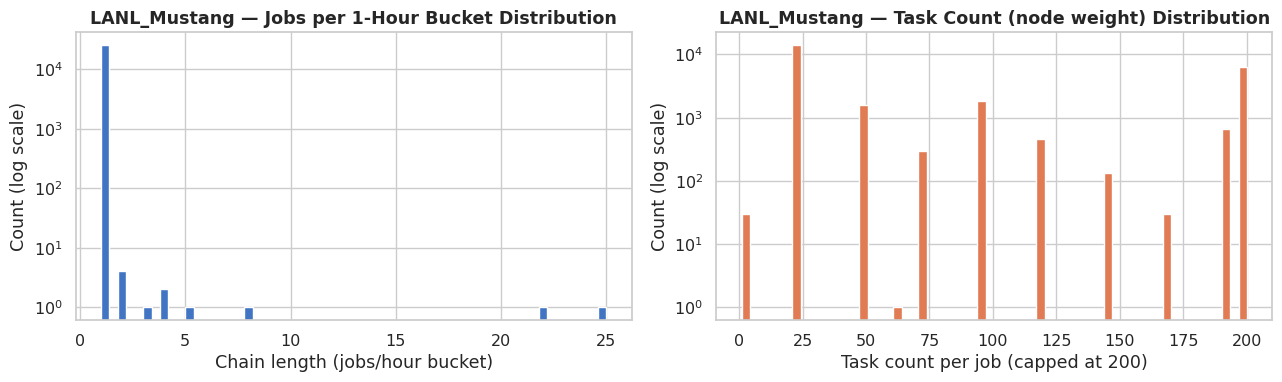

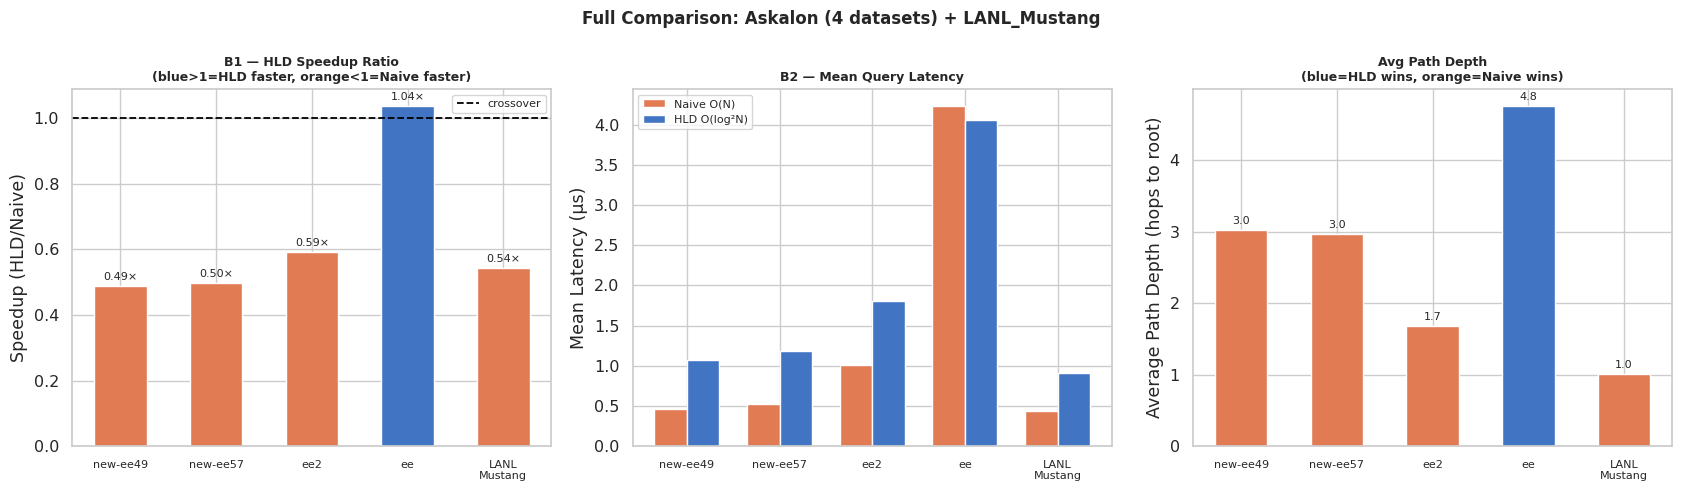

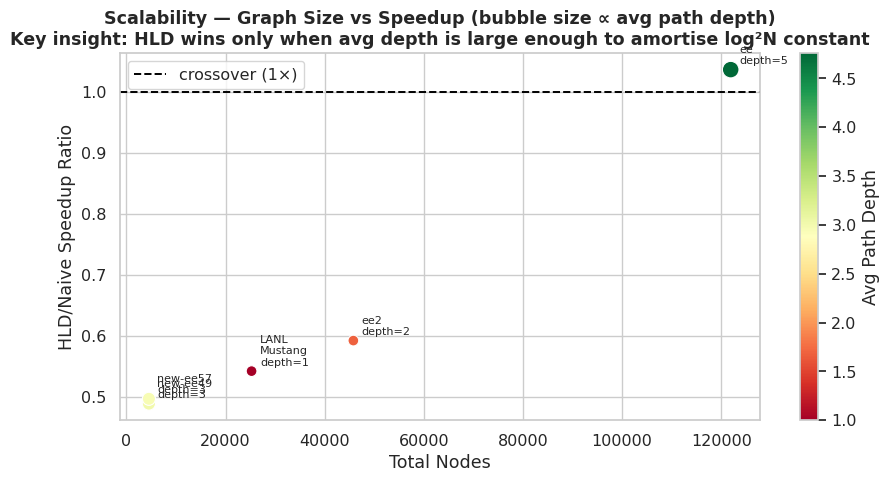

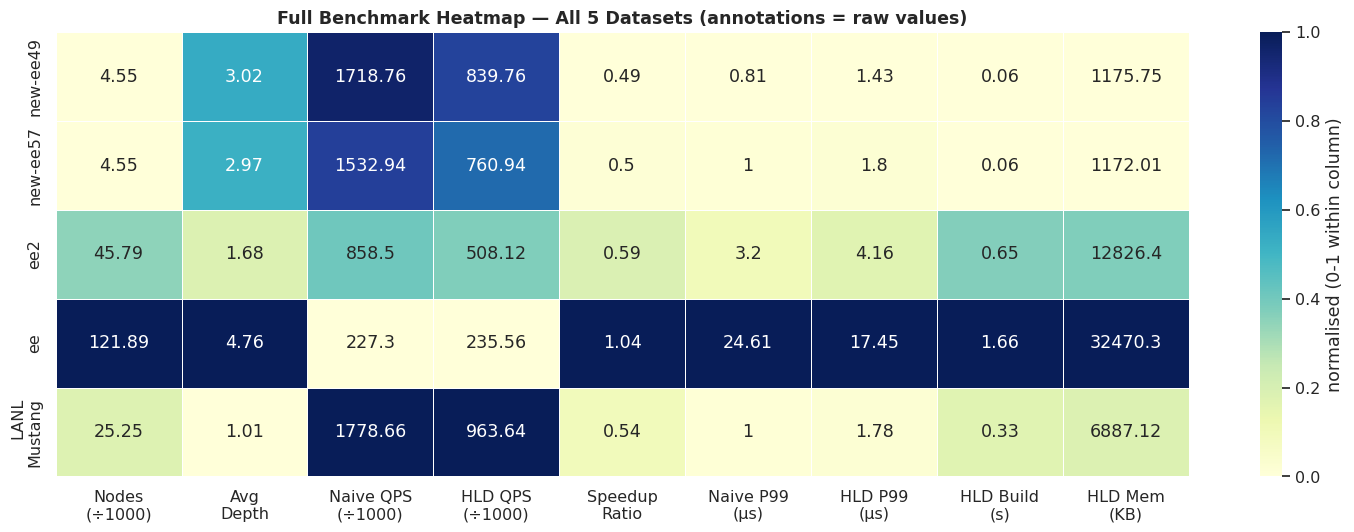

In [13]:
# ── LANL_Mustang specific: chain-length distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(chain_lengths, bins=60, color="#4175c4", edgecolor="white", log=True)
axes[0].set_xlabel("Chain length (jobs/hour bucket)")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("LANL_Mustang — Jobs per 1-Hour Bucket Distribution", fontweight="bold")

wts = lanl_df["task_count"].clip(upper=200)
axes[1].hist(wts, bins=60, color="#e07b54", edgecolor="white", log=True)
axes[1].set_xlabel("Task count per job (capped at 200)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("LANL_Mustang — Task Count (node weight) Distribution", fontweight="bold")
plt.tight_layout(); plt.show()

# ── Combined comparison across ALL 5 datasets ────────────────────────────────
all_ds    = list(all_results_full.keys())
all_short = [short_full[n] for n in all_ds]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (a) Speedup ratio ────────────────────────────────────────────────────────
ax = axes[0]
spds   = [all_results_full[n]["speedup_qps"] for n in all_ds]
colors = ["#4175c4" if s >= 1 else "#e07b54" for s in spds]
bars   = ax.bar(all_short, spds, color=colors, edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.2f×", padding=3, fontsize=8)
ax.axhline(1, color="black", linewidth=1.3, linestyle="--", label="crossover")
ax.set_title("B1 — HLD Speedup Ratio\n(blue>1=HLD faster, orange<1=Naive faster)", fontweight="bold", fontsize=9)
ax.set_ylabel("Speedup (HLD/Naive)"); ax.tick_params(axis="x", labelsize=8); ax.legend(fontsize=8)

# ── (b) Mean query latency (µs) ──────────────────────────────────────────────
ax = axes[1]
x = np.arange(len(all_ds)); w = 0.35
bars_n = ax.bar(x - w/2, [all_results_full[n]["naive_mean_us"] for n in all_ds],
                width=w, label="Naive O(N)", color=PALETTE["Naive O(N)"], edgecolor="white")
bars_h = ax.bar(x + w/2, [all_results_full[n]["hld_mean_us"] for n in all_ds],
                width=w, label="HLD O(log²N)", color=PALETTE["HLD O(log²N)"], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(all_short, fontsize=8)
ax.set_ylabel("Mean Latency (µs)")
ax.set_title("B2 — Mean Query Latency", fontweight="bold", fontsize=9); ax.legend(fontsize=8)

# ── (c) Avg path depth (shows why HLD advantage appears/disappears) ───────────
ax = axes[2]
depths   = [all_results_full[n]["avg_depth"] for n in all_ds]
bar_cols = ["#4175c4" if all_results_full[n]["speedup_qps"] >= 1 else "#e07b54" for n in all_ds]
bars_d   = ax.bar(all_short, depths, color=bar_cols, edgecolor="white", width=0.55)
ax.bar_label(bars_d, fmt="%.1f", padding=3, fontsize=8)
ax.set_ylabel("Average Path Depth (hops to root)")
ax.set_title("Avg Path Depth\n(blue=HLD wins, orange=Naive wins)", fontweight="bold", fontsize=9)
ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Full Comparison: Askalon (4 datasets) + LANL_Mustang", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Scalability scatter: all 5 datasets, bubble = avg_depth ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))
node_counts = [all_results_full[n]["n_nodes"]    for n in all_ds]
avg_depths  = [all_results_full[n]["avg_depth"]  for n in all_ds]
spds2       = [all_results_full[n]["speedup_qps"] for n in all_ds]
sc = ax.scatter(node_counts, spds2,
                s=[max(d * 30, 60) for d in avg_depths],
                c=avg_depths, cmap="RdYlGn", edgecolors="white",
                linewidths=0.8, zorder=5, vmin=1, vmax=max(avg_depths))
plt.colorbar(sc, ax=ax, label="Avg Path Depth")
for name, nc, sp, d in zip(all_ds, node_counts, spds2, avg_depths):
    ax.annotate(f"{short_full[name]}\ndepth={d:.0f}", (nc, sp),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.axhline(1, color="black", linewidth=1.4, linestyle="--", label="crossover (1×)")
ax.set_xlabel("Total Nodes"); ax.set_ylabel("HLD/Naive Speedup Ratio")
ax.set_title(
    "Scalability — Graph Size vs Speedup (bubble size ∝ avg path depth)\n"
    "Key insight: HLD wins only when avg depth is large enough to amortise log²N constant",
    fontweight="bold"
)
ax.legend(); plt.tight_layout(); plt.show()

# ── Combined heatmap ─────────────────────────────────────────────────────────
heat_data_full = pd.DataFrame({
    "Nodes\n(÷1000)"        : [all_results_full[n]["n_nodes"]      / 1000 for n in all_ds],
    "Avg\nDepth"            : [all_results_full[n]["avg_depth"]            for n in all_ds],
    "Naive QPS\n(÷1000)"    : [all_results_full[n]["naive_qps"]    / 1000 for n in all_ds],
    "HLD QPS\n(÷1000)"      : [all_results_full[n]["hld_qps"]      / 1000 for n in all_ds],
    "Speedup\nRatio"        : [all_results_full[n]["speedup_qps"]          for n in all_ds],
    "Naive P99\n(µs)"       : [all_results_full[n]["naive_p99_us"]         for n in all_ds],
    "HLD P99\n(µs)"         : [all_results_full[n]["hld_p99_us"]           for n in all_ds],
    "HLD Build\n(s)"        : [all_results_full[n]["hld_build_s"]          for n in all_ds],
    "HLD Mem\n(KB)"         : [all_results_full[n]["hld_build_mem_kb"]     for n in all_ds],
}, index=all_short)

# Normalise each column for colour, annotate with raw values
heat_norm_full = (heat_data_full - heat_data_full.min()) / (
    heat_data_full.max() - heat_data_full.min() + 1e-12
)
fig, ax = plt.subplots(figsize=(15, max(4, len(all_ds) * 1.1)))
sns.heatmap(heat_norm_full, annot=heat_data_full.round(2), fmt="g",
            cmap="YlGnBu", linewidths=0.6, ax=ax,
            cbar_kws={"label": "normalised (0-1 within column)"})
ax.set_title("Full Benchmark Heatmap — All 5 Datasets (annotations = raw values)",
             fontweight="bold")
plt.tight_layout(); plt.show()
